# Introduction to data wrangling using _`polars`_.

For this expercise, we will utilize two files (listed below) from the 'Brazilian E-Commerce Public Dataset' originally posted on [Kaggle]( https://www.kaggle.com/olistbr/brazilian-ecommerce). We will read these datasets from the github repository for this class.

### Import packages

In [41]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

### Set-up

In [23]:
# location of the 'orders' dataset
orders_file = '../data/olist_orders.csv'
# location of the 'customer' dataset
cust_file = '../data/olist_customers.csv'

### Read data

In [24]:
orders = pl.read_csv(orders_file)

orders.shape

(99441, 8)

In [25]:
orders.head()

order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
str,str,str,str,str,str,str,str
"""e481f51cbdc54678b7cc49136f2d6a…","""9ef432eb6251297304e76186b10a92…","""delivered""","""2017-10-02 10:56:33""","""2017-10-02 11:07:15""","""2017-10-04 19:55:00""","""2017-10-10 21:25:13""","""2017-10-18 00:00:00"""
"""53cdb2fc8bc7dce0b6741e21502734…","""b0830fb4747a6c6d20dea0b8c802d7…","""delivered""","""2018-07-24 20:41:37""","""2018-07-26 03:24:27""","""2018-07-26 14:31:00""","""2018-08-07 15:27:45""","""2018-08-13 00:00:00"""
"""47770eb9100c2d0c44946d9cf07ec6…","""41ce2a54c0b03bf3443c3d931a3670…","""delivered""","""2018-08-08 08:38:49""","""2018-08-08 08:55:23""","""2018-08-08 13:50:00""","""2018-08-17 18:06:29""","""2018-09-04 00:00:00"""
"""949d5b44dbf5de918fe9c16f97b45f…","""f88197465ea7920adcdbec7375364d…","""delivered""","""2017-11-18 19:28:06""","""2017-11-18 19:45:59""","""2017-11-22 13:39:59""","""2017-12-02 00:28:42""","""2017-12-15 00:00:00"""
"""ad21c59c0840e6cb83a9ceb5573f81…","""8ab97904e6daea8866dbdbc4fb7aad…","""delivered""","""2018-02-13 21:18:39""","""2018-02-13 22:20:29""","""2018-02-14 19:46:34""","""2018-02-16 18:17:02""","""2018-02-26 00:00:00"""


Notice how the `type` of each column is also displayed in the output.

In [26]:
# let's take a look at order_status 

orders.group_by('order_status').len().sort(by='len', descending=True)

order_status,len
str,u32
"""delivered""",96478
"""shipped""",1107
"""canceled""",625
"""unavailable""",609
"""invoiced""",314
"""processing""",301
"""created""",5
"""approved""",2


For this exercise, we will use only four columns from this data frame: `order_id`, `customer_id`, `order_status`, `order_purchase_date`. Let's drop the other columns.

In [27]:
# keep only those columns that we need

orders = orders.select(
    pl.col('order_id'),
    pl.col('customer_id'),
    pl.col('order_status'),
    pl.col('order_purchase_timestamp')
)

orders.shape

(99441, 4)

In [28]:
# let's check the schema after column selection

print(orders.schema)

Schema([('order_id', String), ('customer_id', String), ('order_status', String), ('order_purchase_timestamp', String)])


### Convert `order_purchase_timestamp` from `str` to `datetime`

In [29]:
orders['order_purchase_timestamp'].head()

order_purchase_timestamp
str
"""2017-10-02 10:56:33"""
"""2018-07-24 20:41:37"""
"""2018-08-08 08:38:49"""
"""2017-11-18 19:28:06"""
"""2018-02-13 21:18:39"""
"""2017-07-09 21:57:05"""
"""2017-04-11 12:22:08"""
"""2017-05-16 13:10:30"""
"""2017-01-23 18:29:09"""


In [30]:
# date-time conversion

orders = orders.with_columns(
    pl.col('order_purchase_timestamp').str.to_datetime().alias('order_purchase_timestamp'))\
    .with_columns(
        # Convert the timestamp to a date object
        pl.col('order_purchase_timestamp').dt.date().alias('order_purchase_date')
    )

orders['order_purchase_timestamp'].dtype

Datetime(time_unit='us', time_zone=None)

In [31]:
orders.schema

Schema([('order_id', String),
        ('customer_id', String),
        ('order_status', String),
        ('order_purchase_timestamp', Datetime(time_unit='us', time_zone=None)),
        ('order_purchase_date', Date)])

In [32]:
orders.select(['order_purchase_timestamp', 'order_purchase_date']).head()

order_purchase_timestamp,order_purchase_date
datetime[μs],date
2017-10-02 10:56:33,2017-10-02
2018-07-24 20:41:37,2018-07-24
2018-08-08 08:38:49,2018-08-08
2017-11-18 19:28:06,2017-11-18
2018-02-13 21:18:39,2018-02-13


In [9]:
# for this exercise, we won't use the time-stamp
# let's convert the order purchase date-timestamps into dates

orders['order_purchase_date'] = orders['order_purchase_timestamp'].dt.date

# view these two columns
orders[['order_purchase_timestamp', 'order_purchase_date']].head()

,order_purchase_timestamp,order_purchase_date
0,2017-10-02 10:56:33,2017-10-02
1,2018-07-24 20:41:37,2018-07-24
2,2018-08-08 08:38:49,2018-08-08
3,2017-11-18 19:28:06,2017-11-18
4,2018-02-13 21:18:39,2018-02-13


### Daily order volumes

In [37]:
# group by order date and count the number of orders (for each date)

order_counts = orders.group_by('order_purchase_date').agg(pl.len().alias('order_count')).sort('order_purchase_date')

order_counts.head()

order_purchase_date,order_count
date,u32
2016-09-04,1
2016-09-05,1
2016-09-13,1
2016-09-15,1
2016-10-02,1


Plot the daily order volume.

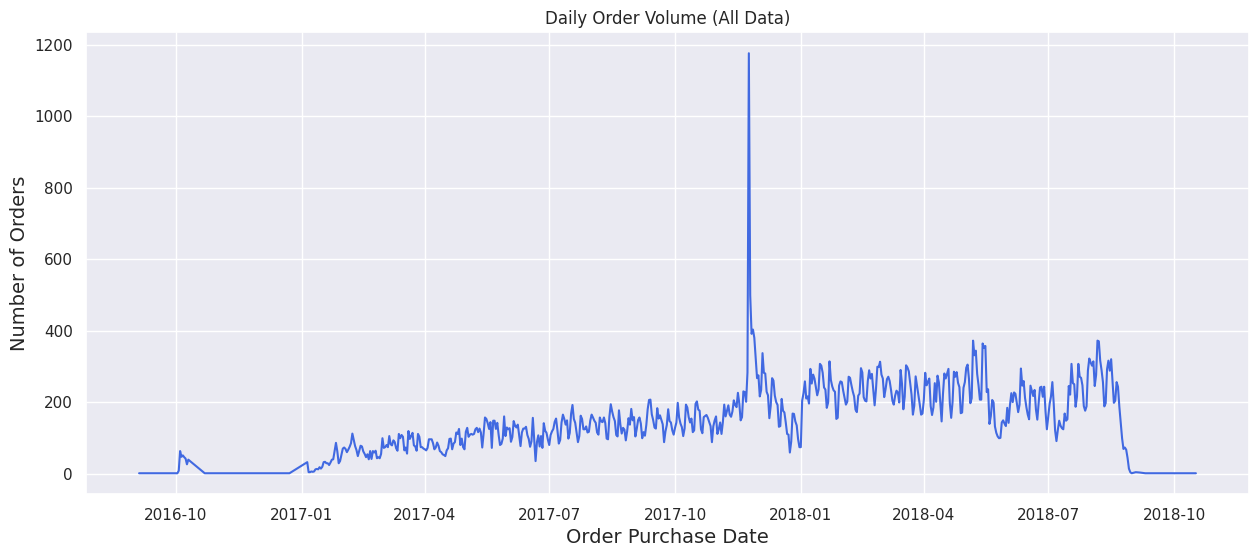

In [38]:
x_data = order_counts['order_purchase_date'].to_numpy()
y_data = order_counts['order_count'].to_numpy()

sns.set(style='darkgrid')
plt.figure(figsize=[15, 6])

sns.lineplot(x=x_data, 
             y=y_data, 
             color='royalblue')

plt.ylabel('Number of Orders', fontsize=14)
plt.xlabel('Order Purchase Date', fontsize=14)
plt.title('Daily Order Volume (All Data)')
plt.show();

Some of the recent data seem to be missing or incomplete. Let's take a closer look.

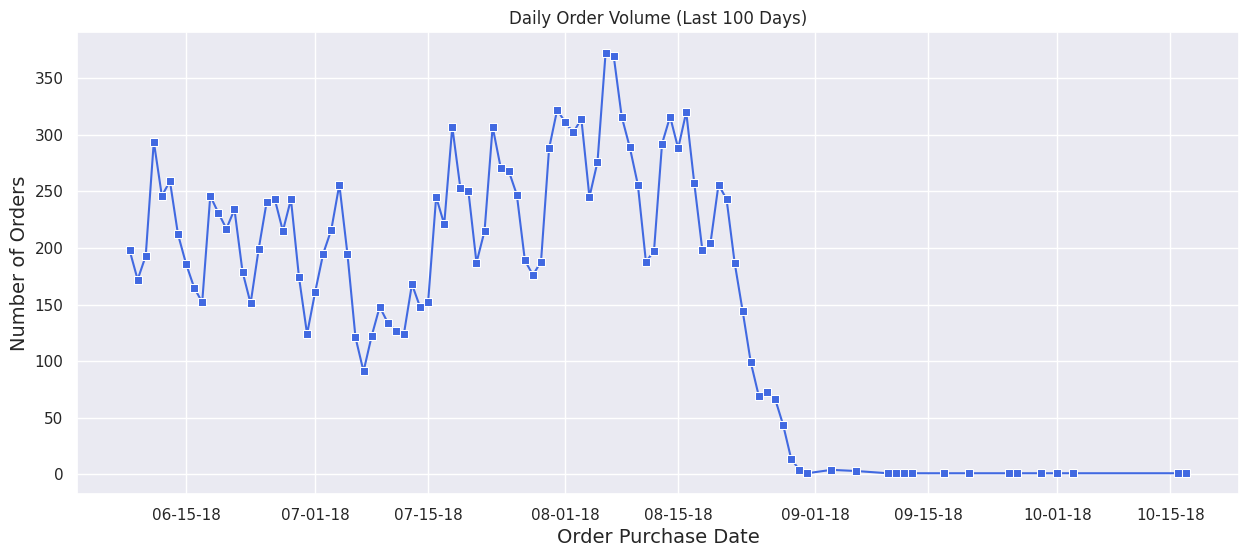

In [42]:
last_100_counts = order_counts.tail(100)
x_data_tail = last_100_counts['order_purchase_date'].to_numpy()
y_data_tail = last_100_counts['order_count'].to_numpy()

sns.set(style='darkgrid')
fig, ax = plt.subplots(figsize=[15, 6])

sns.lineplot(x=x_data_tail, 
             y=y_data_tail, 
             marker='s', 
             color='royalblue')

plt.ylabel('Number of Orders', fontsize=14)
plt.xlabel('Order Purchase Date', fontsize=14)
plt.title('Daily Order Volume (Last 100 Days)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%y'))
plt.show();

It appears that perhaps 8/22 is the most recent day with complete data. We should discard the data after that date.

In [44]:
from datetime import date

max_date = date(2018, 8, 22)

# size of the dataset before applying the date filter
print(orders.shape[0])

# apply the date filter
orders = orders.filter(
    pl.col('order_purchase_date') <= pl.lit(max_date)
)

# size of the dataset after applying the date filter
print(orders.shape[0])

98906
98906


In [46]:
# check
orders['order_purchase_date'].max()

datetime.date(2018, 8, 22)

There's a huge spike in the number of orders sometime around November/December 2017. Let's identify that specific day.

In [48]:
# find the date associated with the maximum daily order volume

max_orders_row = order_counts.filter(pl.col('order_count') == pl.col('order_count').max())
max_orders_row

order_purchase_date,order_count
date,u32
2017-11-24,1176


In [50]:
spike_date = max_orders_row.select('order_purchase_date').item()
spike_date

datetime.date(2017, 11, 24)

In [52]:
# let's check the order_status for these orders

orders.filter(pl.col('order_purchase_date') == pl.lit(spike_date)).group_by('order_status').len().sort(by='len', descending=True)

order_status,len
str,u32
"""delivered""",1147
"""shipped""",12
"""unavailable""",10
"""invoiced""",4
"""processing""",3


In [57]:
# let's take a look at the order hour (hour of day) for these orders

hour_counts = orders.filter(
    pl.col('order_purchase_date') == pl.lit(spike_date)
).with_columns(
    pl.col('order_purchase_timestamp').dt.hour().alias('order_hour')
).group_by('order_hour').len().sort(by='order_hour', descending=False)

pl.Config.set_tbl_rows(-1)
print(hour_counts)
pl.Config.restore_defaults()

shape: (24, 2)
┌────────────┬─────┐
│ order_hour ┆ len │
│ ---        ┆ --- │
│ i8         ┆ u32 │
╞════════════╪═════╡
│ 0          ┆ 55  │
│ 1          ┆ 37  │
│ 2          ┆ 16  │
│ 3          ┆ 5   │
│ 4          ┆ 4   │
│ 5          ┆ 3   │
│ 6          ┆ 9   │
│ 7          ┆ 17  │
│ 8          ┆ 41  │
│ 9          ┆ 55  │
│ 10         ┆ 75  │
│ 11         ┆ 56  │
│ 12         ┆ 64  │
│ 13         ┆ 76  │
│ 14         ┆ 67  │
│ 15         ┆ 68  │
│ 16         ┆ 57  │
│ 17         ┆ 53  │
│ 18         ┆ 49  │
│ 19         ┆ 63  │
│ 20         ┆ 64  │
│ 21         ┆ 77  │
│ 22         ┆ 87  │
│ 23         ┆ 78  │
└────────────┴─────┘


polars.config.Config

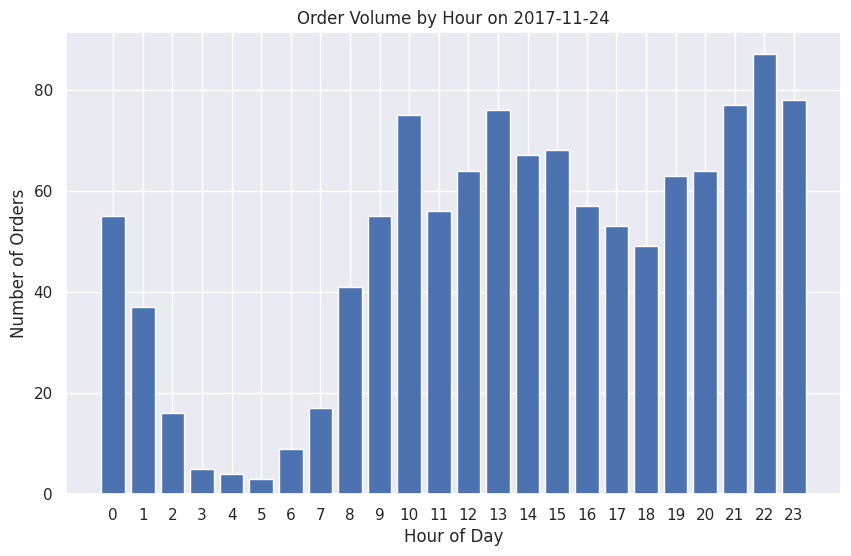

In [58]:
# let's plot it

hour_data = hour_counts.to_dict(as_series=False)

plt.figure(figsize=[10, 6])
plt.bar(hour_data['order_hour'], hour_data['len'])
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.title(f'Order Volume by Hour on {spike_date}')
plt.xticks(hour_data['order_hour'])
plt.show()

This type of finding would be a good opportunity to talk with the stakeholders to find out the reason(s) behind this anomaly/spike. Here are some potential reasons for this spike: a big one-day sale event (Thanksgiving), big product launch, platform launch (e.g., a new marketplace) on that day.

### Is there a monthly seasonality in the order volumes?

In [60]:
# extract year from the order date

orders = orders.with_columns(
    pl.col('order_purchase_timestamp').dt.year().alias('order_year'),
    pl.col('order_purchase_timestamp').dt.month().alias('order_month')
)

orders.group_by('order_year').len().sort(by='len', descending=True)

order_year,len
i32,u32
2018,53476
2017,45101
2016,329


Note: `value_counts()` sorts the results by using the counts in a descending order.

In [64]:
# extract month from the order date

total_orders = orders.height  # total number of rows

month_proportions = (
    orders.group_by('order_month')
    .len()
    .sort('order_month')
    .with_columns(
        (pl.col('len') / total_orders * 100).alias('proportion')
    )
)

month_proportions

order_month,len,proportion
i8,u32,f64
1,8069,8.158251
2,8508,8.602107
3,9893,10.002427
4,9343,9.446343
5,10573,10.689948
…,…,…
8,10328,10.442238
9,4289,4.336441
10,4955,5.009807


In [66]:
# group by year and month to get the number of orders for each combination

order_counts_by_month = orders.group_by(['order_year', 'order_month']).len().sort(['order_year', 'order_month']).rename({'len': 'order_count'})

order_counts_by_month

order_year,order_month,order_count
i32,i8,u32
2016,9,4
2016,10,324
2016,12,1
2017,1,800
2017,2,1780
…,…,…
2018,4,6939
2018,5,6873
2018,6,6167


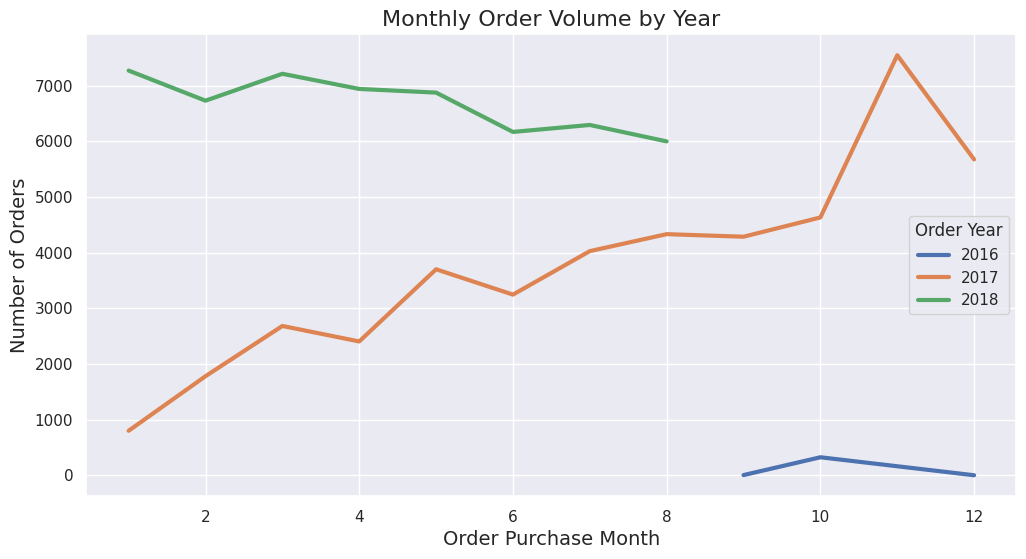

In [70]:
# Extract columns as NumPy arrays for Matplotlib
months = order_counts_by_month['order_month'].to_numpy()
years = order_counts_by_month['order_year'].unique().to_list()

plt.figure(figsize=(12, 6))

# Plot one line per year
for y in years:
    data = order_counts_by_month.filter(pl.col('order_year') == y)
    plt.plot(
        data['order_month'].to_numpy(),
        data['order_count'].to_numpy(),
        lw=3,
        label=str(y)
    )

plt.ylabel('Number of Orders', fontsize=14)
plt.xlabel('Order Purchase Month', fontsize=14)
plt.title('Monthly Order Volume by Year', fontsize=16)
plt.legend(title='Order Year')
plt.show()


The data from 2018 in incomplete (available until August), and only three months' worth of data is available from 2017. But based on the available data, there doesn't appear to be any strong seasonality effect over months. 

### Let's take a look at some customer-level patterns

The `customer_id` that's available in the `olist_orders_dataset` file is *not* unique for each customer. The `olist_customers_dataset` file contains the unique identifier for each customer.

In [71]:
# read the file that contains the unique customer identifier

cust = pl.read_csv(cust_file)

cust.shape

(99441, 5)

In [72]:
cust.head()

customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
str,str,i64,str,str
"""06b8999e2fba1a1fbc88172c00ba8b…","""861eff4711a542e4b93843c6dd7feb…",14409,"""franca""","""SP"""
"""18955e83d337fd6b2def6b18a428ac…","""290c77bc529b7ac935b93aa66c333d…",9790,"""sao bernardo do campo""","""SP"""
"""4e7b3e00288586ebd08712fdd0374a…","""060e732b5b29e8181a18229c7b0b2b…",1151,"""sao paulo""","""SP"""
"""b2b6027bc5c5109e529d4dc6358b12…","""259dac757896d24d7702b9acbbff3f…",8775,"""mogi das cruzes""","""SP"""
"""4f2d8ab171c80ec8364f7c12e35b23…","""345ecd01c38d18a9036ed96c73b8d0…",13056,"""campinas""","""SP"""


In [73]:
# let's keep only the following two columns: customer_id, customer_unique_id

cust = cust.select('customer_id', 'customer_unique_id')

Merge the orders dataframe with the customer dataframe to append `customer_unique_id` to the orders data.

In [74]:
# merge orders and cust dataframes

orders = orders.join(cust, on='customer_id', how='inner')

orders.shape

(98906, 8)

Note that an `inner` join is fine here because customers that are present in one dataframe are all also present in the other dataframe.

In [77]:
# confirm how many unique customer IDs we had in the 'orders' dataset

orders['customer_id'].n_unique()

98906

In [78]:
# number of orders per customer

orders.group_by('customer_unique_id').len().sort(by='len', descending=True).head()

customer_unique_id,len
str,u32
"""8d50f5eadf50201ccdcedfb9e2ac84…",17
"""3e43e6105506432c953e165fb2acf4…",9
"""6469f99c1f9dfae7733b25662e7f17…",7
"""1b6c7548a2a1f9037c1fd3ddfed95f…",7
"""ca77025e7201e3b30c44b472ff3462…",7


In [79]:
# save these counts (number of orders) in a new dataframe
cust_orders = orders.group_by('customer_unique_id').len().rename({'len': 'orders'})

cust_orders.head()

customer_unique_id,orders
str,u32
"""a61f3d42fe066b53106cec5ad80499…",1
"""a9403b325f6e6619eaf3cfe9af0773…",1
"""5194da8c46e3c476a0a031855604ab…",1
"""d1d186734a9f49e86b2d700d16bbcf…",1
"""2af088e64be11bcaa84f33d9cb9196…",1


In [80]:
# number of customers by their order volume

order_volume_counts = cust_orders.group_by('orders').len().sort('orders')
order_volume_counts

orders,len
u32,u32
1,92646
2,2715
3,196
4,30
5,9
6,5
7,3
9,1
17,1


Most customers ordered only once :(

What % of customers ordered only once?

In [81]:
# % of customers by their order volume

order_volume_counts.with_columns(
        (pl.col('len') / pl.col('len').sum()).alias('proportion')
    )

orders,len,proportion
u32,u32,f64
1,92646,0.96904
2,2715,0.028398
3,196,0.00205
4,30,0.000314
5,9,0.000094
6,5,0.000052
7,3,0.000031
9,1,0.00001
17,1,0.00001
